<a href="https://colab.research.google.com/github/sauraviitj/neural-networks-zero-to-hero/blob/main/2%20%2C%203%2C%204%20Makemore/movie_dialogue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import re
import unicodedata

def clean_quote(text: str) -> str:
    # 1) Normalize unicode
    text = unicodedata.normalize("NFKC", text)

    # 2) Remove non-printable characters
    text = "".join(ch for ch in text if ch.isprintable())

    # 3) Remove ALL punctuation except apostrophes (keep letters, digits, spaces, apostrophes)
    text = re.sub(r"[^A-Za-z0-9\s']", " ", text)

    # 4) Collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

input_path = "/content/moviequotes.memorable_quotes.txt"   # your raw file
output_path = "/content/memorable_quotes.txt"

clean_quotes = []

with open(input_path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue  # skip empty lines

        # keep only lines that DO NOT start with a number
        if line[0].isdigit():
            continue

        # clean the quote text
        quote = clean_quote(line)
        if quote:
            clean_quotes.append(quote)

# write cleaned quotes to a new file
with open(output_path, "w", encoding="utf-8") as f:
    for q in clean_quotes:
        f.write(q + "\n")   # or q + " \n" if you want a trailing space

print(f"Saved {len(clean_quotes)} quotes to {output_path}")

Saved 12531 quotes to /content/memorable_quotes.txt


In [2]:
all_lines = open('/content/memorable_quotes.txt', 'r', encoding='latin').read().splitlines() #open file in read mode, splitlines converts it into list

In [3]:
all_lines[:10]

['Who knocked up your sister',
 "I was watching you out there before I've never seen you look so sexy",
 "You're 18 you don't know what you want And you won't know what you want 'til you're 45 and even if you get it you'll be too old to use it",
 'Ooh see that there Who needs affection when I have blind hatred',
 "Just 'cause you're beautiful that doesn't mean that you can treat people like they don't matter",
 "You're asking me out That's so cute What's your name again",
 "Leave it to you to use big words when you're smashed",
 "And I'm BACK IN THE GAME",
 'I guess in this society being male and an asshole makes you worthy of our time',
 "I have a dick on my face don't I"]

In [4]:
len(all_lines)

12531

In [7]:
lines=all_lines[:4000]
print(len(lines))

4000


In [8]:
import re
import unicodedata
cleaned_lines=[]
def clean_quote(text: str) -> str:
    # 1) Normalize unicode
    text = unicodedata.normalize("NFKC", text)

    # 2) Remove non-printable characters
    text = "".join(ch for ch in text if ch.isprintable())

    # 3) Remove ALL punctuation except apostrophes (keep letters, digits, spaces, apostrophes)
    #    Anything not [A-Za-z0-9 whitespace ' ] becomes a space.
    text = re.sub(r"[^A-Za-z0-9\s']", " ", text)

    # 4) Collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

for i in range(len(lines)):
  cleaned_lines.append(clean_quote(lines[i]))



In [9]:
cleaned_lines[:5]

['Who knocked up your sister',
 "I was watching you out there before I've never seen you look so sexy",
 "You're 18 you don't know what you want And you won't know what you want 'til you're 45 and even if you get it you'll be too old to use it",
 'Ooh see that there Who needs affection when I have blind hatred',
 "Just 'cause you're beautiful that doesn't mean that you can treat people like they don't matter"]

In [10]:
# create word stream
all_text = " ".join(cleaned_lines)   # big string of all quotes
print(all_text[:100])
words = all_text.split()            # list of tokens (strings)
print(words[:3])

# words might look like:
# ['things', 'i', 'hate', 'about', 'you', 'Who', 'knocked', 'up', 'your', 'sister', ...]

Who knocked up your sister I was watching you out there before I've never seen you look so sexy You'
['Who', 'knocked', 'up']


In [11]:
from collections import Counter

# words is your full list of word tokens, e.g. from " ".join(cleaned_lines).split()
# 1) build vocabulary of unique words
word_counts = Counter(words)
vocab = sorted(word_counts.keys())   # list of unique words

# 2) build mappings: word -> index, index -> word
# reserve 0 for a special token (like '.' in Karpathy's example, or <PAD>/<UNK>)
stoi = {w: i+1 for i, w in enumerate(vocab)}  # start from 1
stoi["."] = 0                             # or "<UNK>" etc.

itos = {i: w for w, i in stoi.items()}

print("vocab_size:", len(stoi))
print("example stoi entry:", list(stoi.items())[:10])
print("example itos entry:", {k: itos[k] for k in list(itos.keys())[:10]})

vocab_size: 7012
example stoi entry: [("'", 1), ("'80s", 2), ("'95", 3), ("'Cause", 4), ("'Co", 5), ("'Cobb", 6), ("'Cohee", 7), ("'Course", 8), ("'E'", 9), ("'I", 10)]
example itos entry: {1: "'", 2: "'80s", 3: "'95", 4: "'Cause", 5: "'Co", 6: "'Cobb", 7: "'Cohee", 8: "'Course", 9: "'E'", 10: "'I"}


In [12]:
vocab_size = len(itos)
print(vocab_size)

7012


In [13]:
import torch
import random

block_size = 3  # context length: how many WORDS to take to predict the next one?

def build_dataset(lines):
    X, Y = [], []
    for line in lines:
        tokens = line.split()        # list of words in this sentence
        context = [0] * block_size   # start with all pads

        # go through each word plus the end token '.'
        for w in tokens + ['.']:
            ix = stoi[w]             # word -> index

            X.append(context)
            Y.append(ix)

            # slide the context window
            context = context[1:] + [ix]

    X = torch.tensor(X, dtype=torch.long)
    Y = torch.tensor(Y, dtype=torch.long)
    print(X.shape, Y.shape)
    return X, Y

# shuffle sentences, then split into train/dev/test
random.seed(42)
random.shuffle(cleaned_lines)

n1 = int(0.8 * len(cleaned_lines))
n2 = int(0.9 * len(cleaned_lines))
print(n1, n2)

X,   Y   = build_dataset(cleaned_lines)
Xtr, Ytr = build_dataset(cleaned_lines[:n1])
Xdev,Ydev= build_dataset(cleaned_lines[n1:n2])
Xte, Yte = build_dataset(cleaned_lines[n2:])

print("full X shape:", X.shape)

3200 3600
torch.Size([48201, 3]) torch.Size([48201])
torch.Size([38301, 3]) torch.Size([38301])
torch.Size([4880, 3]) torch.Size([4880])
torch.Size([5020, 3]) torch.Size([5020])
full X shape: torch.Size([48201, 3])


In [14]:
import torch

vocab_size = len(stoi)   # includes '.' and any special tokens
n_embd = 2               # or bigger, e.g. 16, 32, 64...

C = torch.randn((vocab_size, n_embd))
print(C.shape)

torch.Size([7012, 2])


In [15]:
emb = C[X]
print(emb[:1])
emb.shape #(X rows, block_size, embed_dimension)

tensor([[[-1.3862, -0.3520],
         [-1.3862, -0.3520],
         [-1.3862, -0.3520]]])


torch.Size([48201, 3, 2])

In [16]:
W1 = torch.randn((6, 10))
b1 = torch.randn(10)

In [17]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # pytorch converts b1 with dim (100,) to (1,100)

In [18]:

W2 = torch.randn((10, vocab_size))
b2 = torch.randn(vocab_size)

In [19]:
logits = h @ W2 + b2

In [20]:
logits.shape

torch.Size([48201, 7012])

In [22]:
counts = logits.exp()
print(counts)

tensor([[4.5932e-01, 1.5808e+00, 1.7758e+00,  ..., 9.6020e+00, 3.8991e-01,
         3.2095e+01],
        [9.9106e-02, 2.0171e-01, 7.2424e-01,  ..., 6.2344e+00, 1.2005e+00,
         1.3965e+02],
        [4.5932e-01, 1.5808e+00, 1.7758e+00,  ..., 9.6020e+00, 3.8991e-01,
         3.2095e+01],
        ...,
        [7.1609e-01, 2.0927e-01, 6.9491e-01,  ..., 6.3050e+01, 3.1894e-01,
         3.9652e-02],
        [5.2845e-01, 2.9174e-01, 6.9754e+00,  ..., 2.0063e+01, 1.4739e-01,
         2.7671e-01],
        [3.4681e+00, 9.2410e-01, 8.8466e-01,  ..., 2.7905e+01, 1.4967e-01,
         5.8661e-01]])


In [23]:
prob = counts / counts.sum(1, keepdims=True)

In [24]:
prob.shape

torch.Size([48201, 7012])

In [25]:
loss = -prob[torch.arange(prob.shape[0]), Y].log().mean()
loss

tensor(12.6759)

with training

In [34]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size, 10), generator=g)
print(C.shape)
W1 = torch.randn((30, 50), generator=g)
b1 = torch.randn(50, generator=g)
W2 = torch.randn((50, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)
parameters = [C, W1, b1, W2, b2]

torch.Size([7012, 10])


In [35]:
sum(p.nelement() for p in parameters) # number of parameters in total

429282

In [39]:
for p in parameters:
  p.requires_grad = True

In [40]:
lre = torch.linspace(-3, 0, 1000) #creates a 1D tensor of 1000 equally spaced values between -3 and 0 (inclusive)
lrs = 10**lre #The resulting lrs tensor contains 1000 values spaced logarithmically from \(10^{-3}\) (\(0.001\)) to \(10^{0}\) (\(1.0\)).
print(lrs.shape)

torch.Size([1000])


In [41]:
lri = []
lossi = []
stepi = []

In [51]:
import torch.nn.functional as F
for i in range(20000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,)) #Pick 32 random row indices from your training data Xtr, they will form a minibatch that you’ll train on in this step.
  #print(ix.shape)

  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10) because Xtr[ix] is 32*3 and C is 27*10, so each element in Xtr[ix] will be a 10 numbered single row
  #print(emb.shape)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200) , as emb.view makes it 32*30 and W1 is 30*200
  logits = h @ W2 + b2 # (32, 27) as h is 32*200 and W2 is 200*27
  loss = F.cross_entropy(logits, Ytr[ix])

  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None #Set all previous gradients to None (clear them).
  loss.backward() # calculates gradients

  # update
  #lr = lrs[i]
  lr = 0.1 if i < 10000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i) #stepi.append(i): remember which step number this is.
  lossi.append(loss.log10().item()) # loss.log10() takes log base 10, so the numbers are easier to plot when they change a lot.

#print(loss.item())

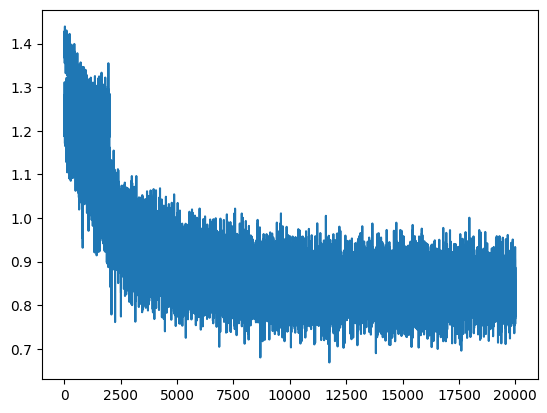

In [52]:
import matplotlib.pyplot as plt # for making figures
%matplotlib inline
plt.plot(stepi, lossi)

In [53]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(6.9615, grad_fn=<NllLossBackward0>)

In [54]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(7.2843, grad_fn=<NllLossBackward0>)

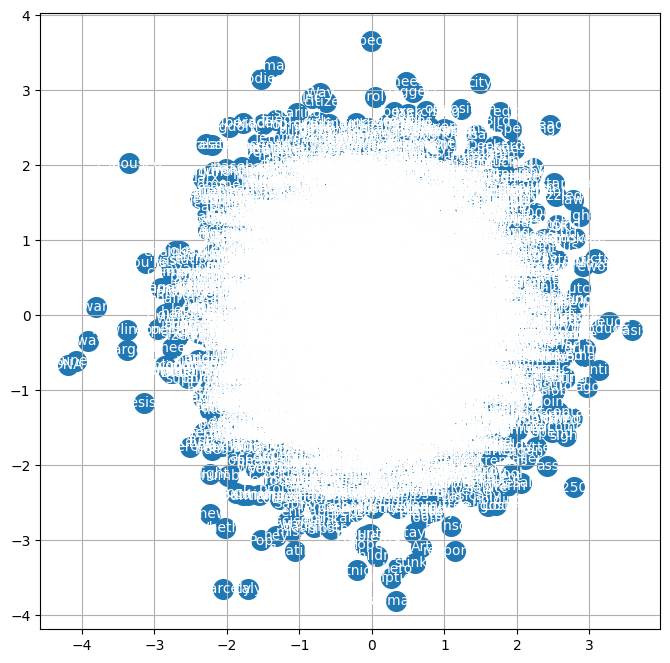

In [47]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [55]:
print(block_size)
context = [0] * block_size
print(context)
C[torch.tensor([context])].shape # C is 27 * 10. so C[context] will be 1*3*10

3
[0, 0, 0]


torch.Size([1, 3, 10])

In [56]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d) C is x* d
      #print(b1.shape)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1) #view[1,-1] make it 2D with 1 row and as many columns as needed whereas, emb.view(-1, 1)make it 2D with 1 column and as many rows as needed
      logits = h @ W2 + b2
     # print(logits.shape)
      probs = F.softmax(logits, dim=1) #dim=1 means “apply softmax across the 27 numbers for each row.”
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(' '.join(itos[i] for i in out))

accident take take under Our of is older pickle very role right the another bad I town braveheart the her The Underestimated a here Ugarte I'm they 'em Cain I've ever a we're paycheck still you Two She Lost but from adaptation grungey concern light too the house all place isn't vice upon paranoia most Pete's and eastern maintenance .
guy .
think all secrets like graffiti stick say hoo who me Let and to your I or a gifts Mrs so crews it fighters .
hard edtv .
malaise road and in was the fight mistake don't people I .
dough goer john Empire .
here stops Holden eve at .
apt get Cain change kid new Mrs men it nationality flier their country the do you back assigned Boy take be .
20 cream tried say stain shop marble is the name life murder gotta Everything finding till of asparagus blow .
eradicating won't .
mention .
blew as is Lennon have piece by of deepest helmets drop 427 .
donnie racing .
want .
off my I'm Rockefeller crazy not a find for the myself nemo club the people first own view